# 00 · Dataset inspection and leaf-level split

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/atilimai/plant-ai-project/blob/main/notebooks/00_dataset_inspection.ipynb)

What this notebook covers (issues #01, #02, #05):

1. download PlantVillage at a pinned revision and verify its checksum,
2. look at the class distribution and a few images per class,
3. understand why the split has to be made per **leaf**, not per image, and how the leaf groups are rebuilt,
4. check the committed split (`data/splits/manifest.csv`) and its leakage audit,
5. eyeball the training augmentations.

Everything heavy lives in `src/`; this notebook only calls it and shows the results.

In [1]:
# Setup: on Colab clone the repo and install deps; locally just move to the repo root.
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not Path("plant-ai-project").exists():
        !git clone -q https://github.com/atilimai/plant-ai-project.git
    %cd plant-ai-project
    !pip install -q -r requirements.txt
else:
    while not Path("configs/data.yaml").exists() and Path.cwd() != Path.cwd().parent:
        os.chdir("..")
sys.path.insert(0, str(Path.cwd()))
print("repo root:", Path.cwd().name)

repo root: plant-ai-project


## 1. Download and prepare

`src.data.prepare` downloads `data.zip` (2.2 GB) from the pinned Hugging Face revision, checks its SHA-256,
extracts the `color` and `segmented` variants, rebuilds leaf groups, splits and audits. It skips every step
whose output already exists, so re-running is cheap. On Colab the download takes a few minutes.

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src.data.labels import PLANTVILLAGE_CLASSES, pretty_name, is_healthy

%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 80

IMAGE_ROOT = Path("data/raw/plantvillage")
if not (IMAGE_ROOT / "color").exists():
    !python -m src.data.prepare --config configs/data.yaml
else:
    print("images already extracted:", sum(1 for _ in (IMAGE_ROOT / "color").rglob("*.*")), "colour files")

images already extracted: 54305 colour files


## 2. Class distribution

54305 images, 38 classes, 14 crops
healthy images: 27.8%; largest/smallest class: 5507 / 152 (36x)


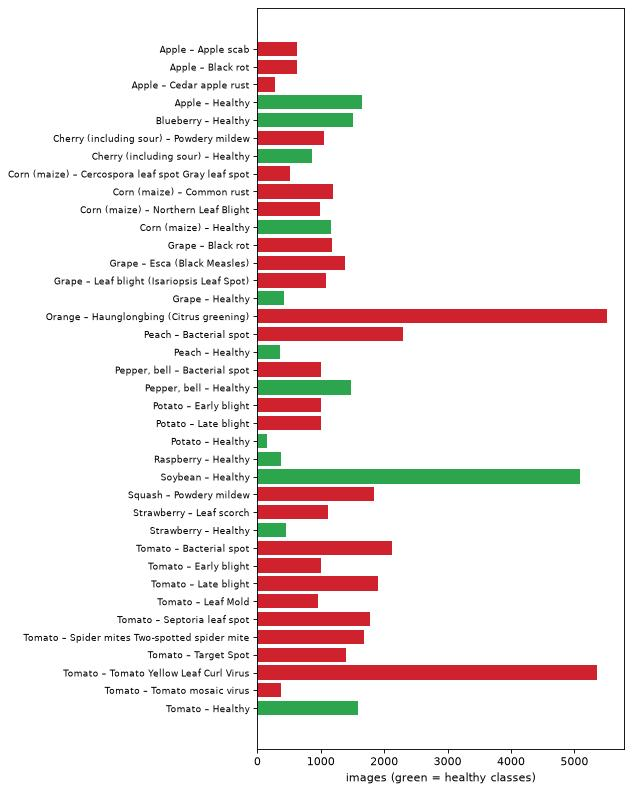

In [3]:
manifest = pd.read_csv("data/splits/manifest.csv")
summary = json.load(open("data/splits/split_summary.json"))

counts = manifest["class_name"].value_counts().reindex(PLANTVILLAGE_CLASSES)
print(f"{len(manifest)} images, {manifest['class_name'].nunique()} classes, "
      f"{manifest['class_name'].str.split('___').str[0].nunique()} crops")
print(f"healthy images: {manifest['class_name'].map(is_healthy).mean():.1%}; "
      f"largest/smallest class: {counts.max()} / {counts.min()} ({counts.max() / counts.min():.0f}x)")

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["#2da44e" if is_healthy(c) else "#cf222e" for c in counts.index]
ax.barh([pretty_name(c) for c in counts.index], counts.values, color=colors)
ax.invert_yaxis()
ax.set_xlabel("images (green = healthy classes)")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()

One random image per class. Note the uniform lab backgrounds: this is exactly why lab accuracy does not transfer to field photos.

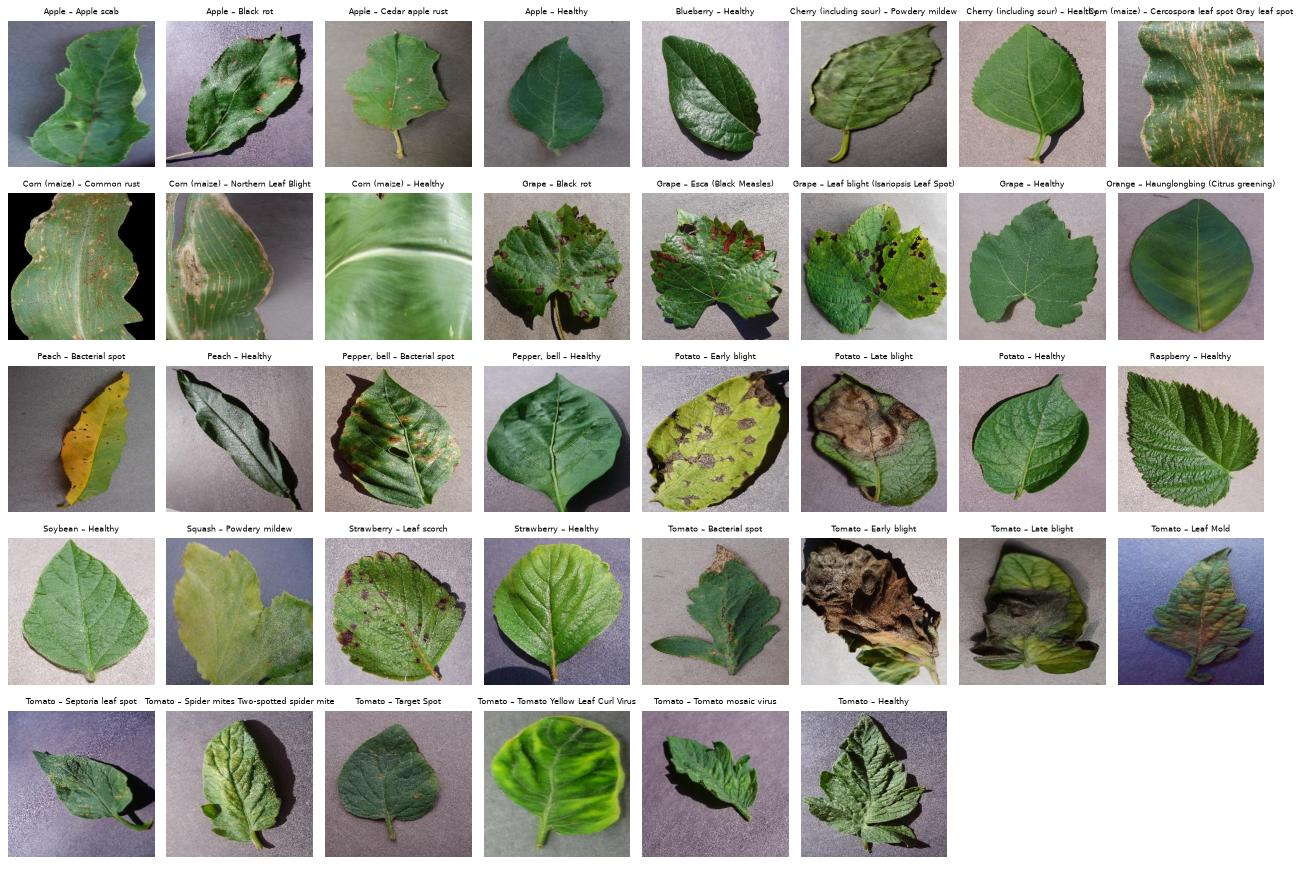

In [4]:
sample = manifest.groupby("class_name").sample(1, random_state=0).set_index("class_name").reindex(PLANTVILLAGE_CLASSES)
fig, axes = plt.subplots(5, 8, figsize=(16, 11))
for ax, (cls, row) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(IMAGE_ROOT / row["path"]))
    ax.set_title(pretty_name(cls), fontsize=7)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()

## 3. Why a leaf-level split, and how the leaf groups are built

PlantVillage contains several photos of every physical leaf. If those photos are spread over train and test,
test accuracy measures memorisation of individual leaves. The dataset does not ship a clean `leaf_id`, so
`src/data/grouping.py` rebuilds one from:

| evidence | covers |
|---|---|
| `leaf-map.json` from the dataset authors (camera file name → leaf number) | ~41k of 54k images |
| identical camera file names (`RS_NLB 3932.JPG`, `… copy.jpg`, `… copy 2.jpg` are crops of one photo) | ~1.4k |
| leaf numbers inside the name (`GHLB_PS Leaf 23.7 Day 13`, a time series of one leaf) | ~0.1k |
| byte-identical files | 21 pairs |

About 13k images (all Corn and Squash, Tomato Target Spot and mosaic virus, Grape healthy, parts of other Tomato
classes) have no author leaf id. For those, each **camera sequence** is cut into contiguous train/val/test
segments and held-out frames within 20 frame numbers of another split are dropped. The frame buffer was picked
by simulating the rule on the images that *do* have leaf ids (hide the ids, split, count leaks):

In [5]:
calib = pd.read_csv("data/splits/grouping_calibration.csv")
calib

,frame_buffer,heldout_purged_share,heldout_sharing_leaf_with_train,test_sharing_leaf_with_val,n_images
0,0,0.0000,0.0156,0.0152,41111
1,5,0.0360,0.0044,0.0037,41111
2,10,0.0711,0.0015,0.0010,41111
3,20,0.1409,0.0000,0.0002,41111
4,30,0.2070,0.0000,0.0002,41111


In [6]:
print("How the images were grouped:")
print(manifest["group_source"].value_counts().to_string())
print()
print("Split rule:")
print(manifest["split_rule"].value_counts().to_string())

sizes = manifest.groupby("group_id").size()
print(f"\n{sizes.size} groups; images per group: median {sizes.median():.0f}, 95th pct {sizes.quantile(.95):.0f}, max {sizes.max()}")

How the images were grouped:
group_source
leaf_map        41099
singleton       11730
camera_frame     1369
named_leaf        107

Split rule:
split_rule
leaf_group         41115
camera_sequence    13190

19950 groups; images per group: median 1, 95th pct 8, max 33


A leaf group from the author leaf map: different photos of the same physical leaf.

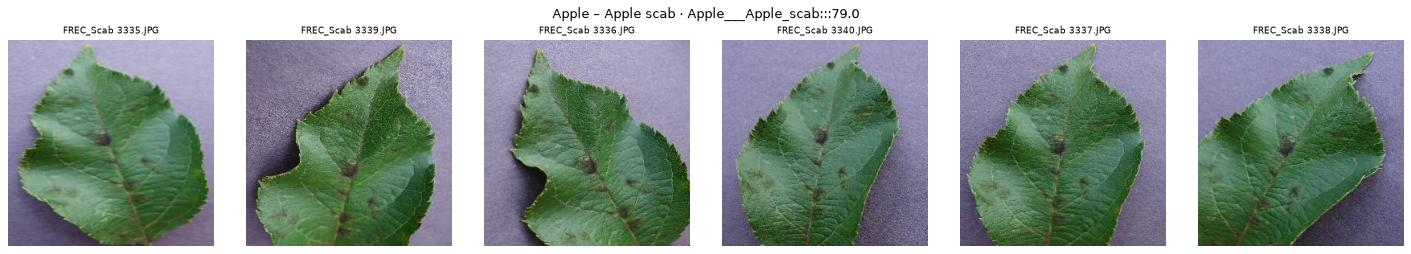

In [7]:
big = manifest[manifest["group_source"] == "leaf_map"].groupby("group_id").filter(lambda g: len(g) >= 6)
example = big[big["group_id"] == big["group_id"].iloc[0]].head(6)
fig, axes = plt.subplots(1, len(example), figsize=(3 * len(example), 3.2))
for ax, (_, row) in zip(axes, example.iterrows()):
    ax.imshow(Image.open(IMAGE_ROOT / row["path"]))
    ax.set_title(Path(row["path"]).name.split("___")[-1], fontsize=8)
    ax.axis("off")
fig.suptitle(f"{pretty_name(example['class_name'].iloc[0])} · {example['leaf_key'].iloc[0]}")
plt.tight_layout()

## 4. The committed split and its leakage audit

In [8]:
audit = json.load(open("data/splits/leakage_audit.json"))
print("audit passed:", audit["passed"])
print("shared between splits:", json.dumps(audit["overlaps"], indent=1))
print("frame-buffer violations:", audit["frame_buffer_violations"])
pd.DataFrame({"images": summary["images_per_split"]}).T

audit passed: True
shared between splits: {
 "group_id": {
  "train-val": 0,
  "train-test": 0,
  "val-test": 0
 },
 "leaf_key": {
  "train-val": 0,
  "train-test": 0,
  "val-test": 0
 },
 "identifier_in_class": {
  "train-val": 0,
  "train-test": 0,
  "val-test": 0
 },
 "md5": {
  "train-val": 0,
  "train-test": 0,
  "val-test": 0
 }
}
frame-buffer violations: 0


,train,val,test,excluded
images,38011,7516,7770,1008


In [9]:
per_class = pd.DataFrame(summary["images_per_class"]).T
per_class["held-out share"] = (per_class["val"] + per_class["test"]) / per_class[["train", "val", "test"]].sum(axis=1)
per_class.sort_values("held-out share").head(10)

,train,val,test,excluded,held-out share
Tomato___Tomato_mosaic_virus,261,16,37,59,0.168790
Grape___healthy,296,24,43,60,0.184573
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,359,37,56,61,0.205752
Corn_(maize)___healthy,814,97,118,133,0.208941
Strawberry___Leaf_scorch,782,110,149,68,0.248799
Corn_(maize)___Northern_Leaf_Blight,689,108,124,64,0.251900
Tomato___Septoria_leaf_spot,1235,192,224,120,0.251969
Tomato___healthy,1124,185,202,80,0.256122
Squash___Powdery_mildew,1284,216,238,97,0.261220
Corn_(maize)___Common_rust_,835,138,159,60,0.262367


The classes at the top of this table are the ones without author leaf ids: the frame buffer removes some of
their val/test images, so their held-out share is a little below 30%. That is the price of not leaking.

The audit is also re-run in CI from the manifest alone: `python scripts/audit_manifest.py`.

## 5. Augmentation sanity check (issue #05)

Flips, 90° rotations, mild crops and colour jitter. Labels must still be obvious after augmentation.

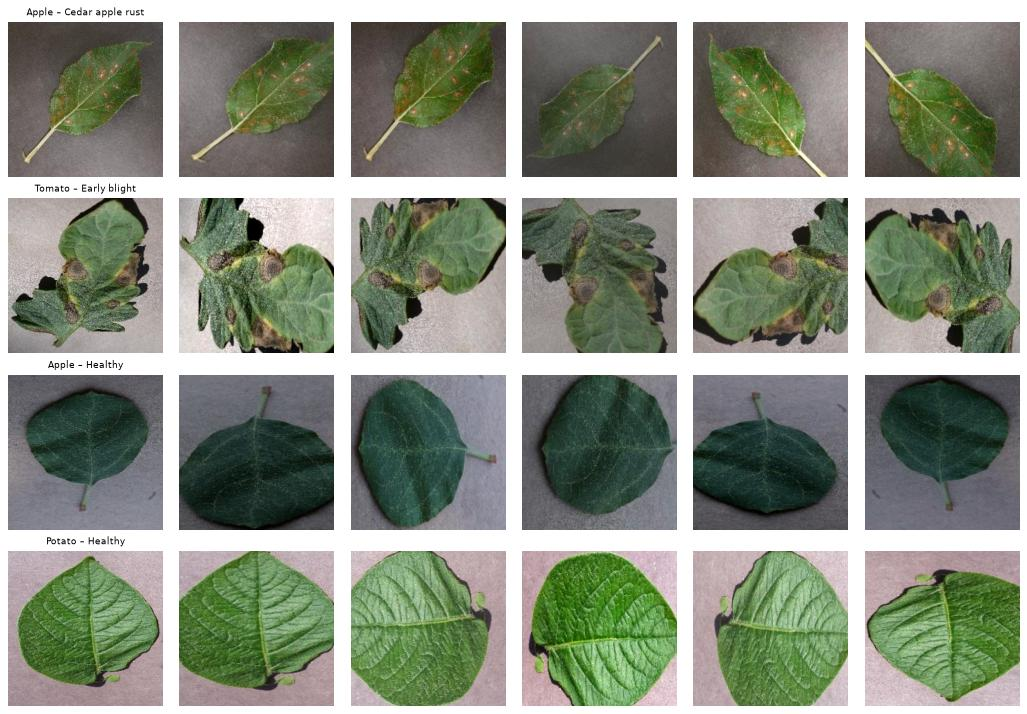

In [10]:
import torch
from src.data.transforms import build_transforms, denormalize

train_tf = build_transforms(train=True, image_size=224)
rows = manifest[manifest["split"] == "train"].groupby("class_name").sample(1, random_state=1).sample(4, random_state=1)
fig, axes = plt.subplots(4, 6, figsize=(13, 9))
torch.manual_seed(0)
for r, (_, row) in enumerate(rows.iterrows()):
    img = Image.open(IMAGE_ROOT / row["path"]).convert("RGB")
    axes[r, 0].imshow(img)
    axes[r, 0].set_title(pretty_name(row["class_name"]), fontsize=8)
    for c in range(1, 6):
        axes[r, c].imshow(denormalize(train_tf(img)).permute(1, 2, 0))
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()